In [2]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [3]:

# Paths
image_dir = r"D:\FYP\Datasets\solar_cell_EL_image\solar_cell_EL_image\PVELAD\EL2021\trainval\JPEGImages"
annotation_dir = r"D:\FYP\Datasets\solar_cell_EL_image\solar_cell_EL_image\PVELAD\EL2021\trainval\Annotations"

# Load data lists
image_files = []
labels = []
bboxes = []

for xml_file in os.listdir(annotation_dir):
    if xml_file.endswith(".xml"):
        xml_path = os.path.join(annotation_dir, xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.find('filename').text
        label = root.find('object').find('name').text

        bbox = root.find('object').find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)

        image_path = os.path.join(image_dir, filename)
        if os.path.exists(image_path):
            image_files.append(image_path)
            labels.append(label)
            bboxes.append([xmin, ymin, xmax, ymax])

print("Total samples found:", len(image_files))

# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Load images as numpy arrays and normalize bbox coordinates
X = []
y_bbox = []
target_size = (256, 256)  # Resize to smaller size for faster training


Total samples found: 4500


In [4]:

for img_path, box in zip(image_files, bboxes):
    img = load_img(img_path, color_mode='grayscale', target_size=target_size)
    img_array = img_to_array(img) / 255.0
    X.append(img_array)

    orig_w, orig_h = 1024, 1024
    new_w, new_h = target_size

    scale_x = new_w / orig_w
    scale_y = new_h / orig_h

    # Normalize bbox between 0 and 1 for regression
    x_min_norm = box[0] * scale_x / new_w
    y_min_norm = box[1] * scale_y / new_h
    x_max_norm = box[2] * scale_x / new_w
    y_max_norm = box[3] * scale_y / new_h

    y_bbox.append([x_min_norm, y_min_norm, x_max_norm, y_max_norm])

X = np.array(X)
y_bbox = np.array(y_bbox)
y_class = np.array(labels_encoded)

print("X shape:", X.shape)
print("y_class shape:", y_class.shape)
print("y_bbox shape:", y_bbox.shape)
print("Classes:", label_encoder.classes_)


X shape: (4500, 256, 256, 1)
y_class shape: (4500,)
y_bbox shape: (4500, 4)
Classes: ['black_core' 'corner' 'crack' 'finger' 'fragment'
 'horizontal_dislocation' 'printing_error' 'scratch' 'short_circuit'
 'star_crack' 'thick_line' 'vertical_dislocation']


In [5]:

X_train, X_test, y_class_train, y_class_test, y_bbox_train, y_bbox_test = train_test_split(
    X, y_class, y_bbox, test_size=0.2, random_state=42)

num_classes = len(label_encoder.classes_)
y_class_train_cat = tf.keras.utils.to_categorical(y_class_train, num_classes)
y_class_test_cat = tf.keras.utils.to_categorical(y_class_test, num_classes)


In [6]:

inputs = tf.keras.Input(shape=(256, 256, 1))

x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)


In [7]:

class_output = tf.keras.layers.Dense(num_classes, activation='softmax', name='class_output')(x)


In [8]:

bbox_output = tf.keras.layers.Dense(4, activation='sigmoid', name='bbox_output')(x)

model = tf.keras.Model(inputs=inputs, outputs=[class_output, bbox_output])

model.compile(optimizer='adam',
              loss={'class_output': 'categorical_crossentropy', 'bbox_output': 'mse'},
              metrics={'class_output': 'accuracy', 'bbox_output': 'mse'})

model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 254, 254, 32)         320       ['input_1[0][0]']             
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)         0         ['conv2d[0][0]']              
 D)                                                                                               
                                                                                                  
 conv2d_1 (Conv2D)           (None, 125, 125, 64)         18496     ['max_pooling2d[0][0]']  

In [9]:

history = model.fit(X_train, {'class_output': y_class_train_cat, 'bbox_output': y_bbox_train},
                    epochs=10, batch_size=16,
                    validation_split=0.2)


Epoch 1/10


180/180 [==============================] - 47s 252ms/step - loss: 1.1062 - class_output_loss: 1.0214 - bbox_output_loss: 0.0848 - class_output_accuracy: 0.5948 - bbox_output_mse: 0.0848 - val_loss: 0.8020 - val_class_output_loss: 0.7418 - val_bbox_output_loss: 0.0602 - val_class_output_accuracy: 0.6972 - val_bbox_output_mse: 0.0602
Epoch 2/10
180/180 [==============================] - 46s 254ms/step - loss: 0.8423 - class_output_loss: 0.7766 - bbox_output_loss: 0.0657 - class_output_accuracy: 0.6712 - bbox_output_mse: 0.0657 - val_loss: 0.8149 - val_class_output_loss: 0.7589 - val_bbox_output_loss: 0.0560 - val_class_output_accuracy: 0.6889 - val_bbox_output_mse: 0.0560
Epoch 3/10
180/180 [==============================] - 46s 256ms/step - loss: 0.7835 - class_output_loss: 0.7246 - bbox_output_loss: 0.0589 - class_output_accuracy: 0.7038 - bbox_output_mse: 0.0589 - val_loss: 0.8090 - val_class_output_loss: 0.7521 - val_bbox_output_loss: 0.0568 - val_class_output_accuracy: 

In [10]:

results = model.evaluate(X_test, {'class_output': y_class_test_cat, 'bbox_output': y_bbox_test})
print("Test results:", results)


29/29 [==============================] - 3s 90ms/step - loss: 0.5821 - class_output_loss: 0.5352 - bbox_output_loss: 0.0469 - class_output_accuracy: 0.8044 - bbox_output_mse: 0.0469
Test results: [0.5820679664611816, 0.5351613759994507, 0.04690654203295708, 0.804444432258606, 0.04690654203295708]


In [1]:

sample_img = np.expand_dims(X_test[6], axis=0)
pred_class, pred_bbox = model.predict(sample_img)

pred_label = label_encoder.inverse_transform([np.argmax(pred_class)])
pred_box = pred_bbox[0]

x_min = int(pred_box[0] * target_size[0])
y_min = int(pred_box[1] * target_size[1])
x_max = int(pred_box[2] * target_size[0])
y_max = int(pred_box[3] * target_size[1])

# Display
plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title(f"Predicted defect: {pred_label[0]}")
plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                                  edgecolor='red', facecolor='none', linewidth=2))
plt.show()


NameError: name 'np' is not defined

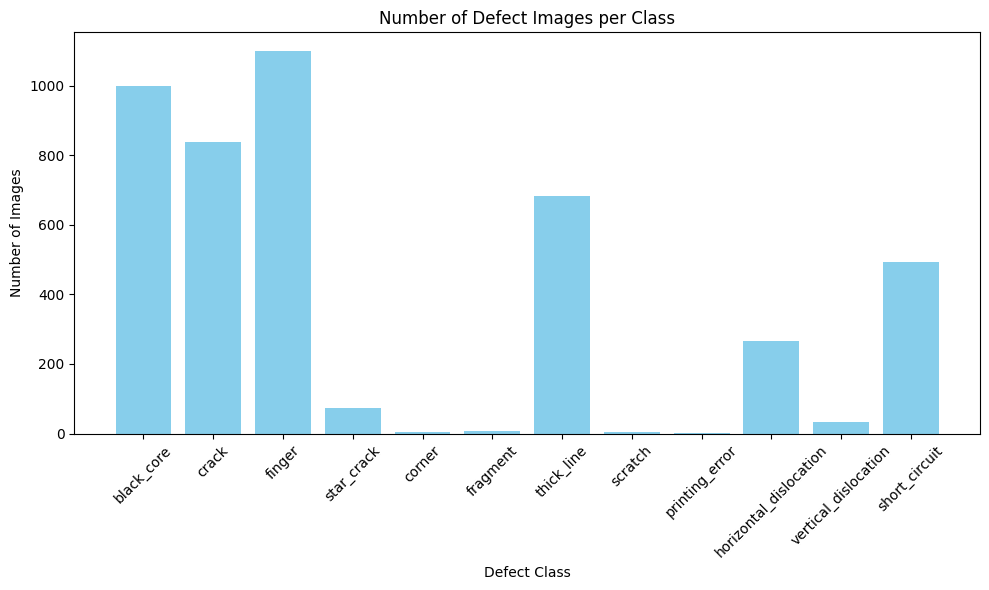

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = [label_counts[c] for c in classes]

# Plot histogram
plt.figure(figsize=(10,6))
plt.bar(classes, counts, color='skyblue')
plt.xlabel('Defect Class')
plt.ylabel('Number of Images')
plt.title('Number of Defect Images per Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
import shutil
import os

# Define target defect types
target_defects = ['finger', 'crack', 'thick_line']  # Use exact names as in your annotation XMLs

# Create output directory
output_dir = r"D:\FYP\Datasets\solar_cell_EL_image\selected_defects"
os.makedirs(output_dir, exist_ok=True)

# Loop through all images and labels
for img_path, label in zip(image_files, labels):
    if label in target_defects:
        # Copy image to output directory
        shutil.copy(img_path, output_dir)

print("Images with target defects copied successfully to:", output_dir)


Images with target defects copied successfully to: D:\FYP\Datasets\solar_cell_EL_image\selected_defects


In [14]:
import os
import xml.etree.ElementTree as ET

# Paths
selected_image_dir = r"D:\FYP\Datasets\solar_cell_EL_image\selected_defects"
annotation_dir = r"D:\FYP\Datasets\solar_cell_EL_image\solar_cell_EL_image\PVELAD\EL2021\trainval\Annotations"

# Initialize counter
multi_defect_images = []

# Loop through selected images
for img_file in os.listdir(selected_image_dir):
    if img_file.endswith(".jpg") or img_file.endswith(".png"):
        # Corresponding XML filename
        xml_filename = os.path.splitext(img_file)[0] + ".xml"
        xml_path = os.path.join(annotation_dir, xml_filename)
        
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            objects = root.findall('object')
            
            if len(objects) > 1:
                multi_defect_images.append(img_file)

# Print results
print("Total images with multiple defects:", len(multi_defect_images))
print("Images with multiple defects:")
for img in multi_defect_images:
    print(img)


Total images with multiple defects: 1298
Images with multiple defects:
img000003.jpg
img000005.jpg
img000006.jpg
img000009.jpg
img000012.jpg
img000015.jpg
img000017.jpg
img000018.jpg
img000020.jpg
img000027.jpg
img000030.jpg
img000032.jpg
img000035.jpg
img000038.jpg
img000039.jpg
img000044.jpg
img000045.jpg
img000047.jpg
img000048.jpg
img000050.jpg
img000051.jpg
img000054.jpg
img000057.jpg
img000060.jpg
img000063.jpg
img000066.jpg
img000069.jpg
img000071.jpg
img000075.jpg
img000078.jpg
img000084.jpg
img000087.jpg
img000089.jpg
img000090.jpg
img000092.jpg
img000095.jpg
img000099.jpg
img000101.jpg
img000104.jpg
img000110.jpg
img000111.jpg
img000114.jpg
img000122.jpg
img000131.jpg
img000132.jpg
img000135.jpg
img000143.jpg
img000144.jpg
img000153.jpg
img000155.jpg
img000156.jpg
img000164.jpg
img000176.jpg
img000180.jpg
img000189.jpg
img000191.jpg
img000192.jpg
img000194.jpg
img000197.jpg
img000204.jpg
img000207.jpg
img000210.jpg
img000213.jpg
img000216.jpg
img000218.jpg
img000219.jpg
img00